# 3. Алгоритм FP-Growth

**FP-Growth** — альтернатива Apriori, будує FP-дерево замість генерації кандидатів.
Переваги: швидший, менше проходів по даних.

Порівняємо результати та час з Apriori.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.frequent_patterns import fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

df = pd.read_csv('data_binned.csv')
df_oh = pd.get_dummies(df, dtype=bool)
print(f"Дані: {df_oh.shape}")

Дані: (26056, 31)


## 3.1 FP-Growth: пошук частих наборів

In [2]:
start = time.time()
frequent_fp = fpgrowth(df_oh, min_support=0.05, use_colnames=True)
fp_time = time.time() - start

print(f"Знайдено {len(frequent_fp)} частих наборів")
print(f"Час FP-Growth: {fp_time:.3f} сек")

apriori_time = pd.read_csv('apriori_time.csv')['time'].values[0]
print(f"Час Apriori:   {apriori_time:.3f} сек")
ratio = apriori_time / fp_time if fp_time > 0 else 0
print(f"FP-Growth {'швидший' if fp_time < apriori_time else 'повільніший'} у {max(ratio, 1/ratio):.1f}x")

frequent_fp.sort_values('support', ascending=False).head(15)

Знайдено 108 частих наборів
Час FP-Growth: 0.084 сек
Час Apriori:   0.043 сек
FP-Growth повільніший у 2.0x


,support,itemsets
5,0.483727,frozenset({age_Middle})
6,0.474094,frozenset({education-num_Edu_Medium})
0,0.452794,frozenset({hours-per-week_FullTime})
7,0.432990,frozenset({marital-status_Mar_Married-civ-spou...
8,0.289722,frozenset({hours-per-week_Overtime})
1,0.286306,frozenset({marital-status_Mar_Never-married})
2,0.272682,frozenset({age_Young})
10,0.257484,frozenset({hours-per-week_PartTime})
9,0.249156,frozenset({education-num_Edu_High})
12,0.243591,frozenset({age_Senior})


## 3.2 Генерація правил

In [3]:
rules_fp = association_rules(frequent_fp, metric='lift', min_threshold=1.0, num_itemsets=len(frequent_fp))
rules_fp = rules_fp.sort_values('lift', ascending=False)
print(f"Знайдено {len(rules_fp)} правил")
rules_fp[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Знайдено 176 правил


,antecedents,consequents,support,confidence,lift
131,frozenset({occupation_Occ_Prof-specialty}),frozenset({education-num_Edu_VeryHigh}),0.054959,0.419695,4.276722
130,frozenset({education-num_Edu_VeryHigh}),frozenset({occupation_Occ_Prof-specialty}),0.054959,0.560031,4.276722
98,"frozenset({marital-status_Mar_Never-married, h...",frozenset({age_Young}),0.078715,0.752384,2.759202
99,frozenset({age_Young}),"frozenset({marital-status_Mar_Never-married, h...",0.078715,0.288670,2.759202
97,"frozenset({age_Young, hours-per-week_PartTime})",frozenset({marital-status_Mar_Never-married}),0.078715,0.787332,2.749963
100,frozenset({marital-status_Mar_Never-married}),"frozenset({age_Young, hours-per-week_PartTime})",0.078715,0.274933,2.749963
15,frozenset({age_Young}),"frozenset({marital-status_Mar_Never-married, e...",0.082092,0.301056,2.266485
14,"frozenset({marital-status_Mar_Never-married, e...",frozenset({age_Young}),0.082092,0.618029,2.266485
4,frozenset({age_Young}),frozenset({marital-status_Mar_Never-married}),0.169059,0.619986,2.165463
5,frozenset({marital-status_Mar_Never-married}),frozenset({age_Young}),0.169059,0.590483,2.165463


## 3.3 Візуалізація

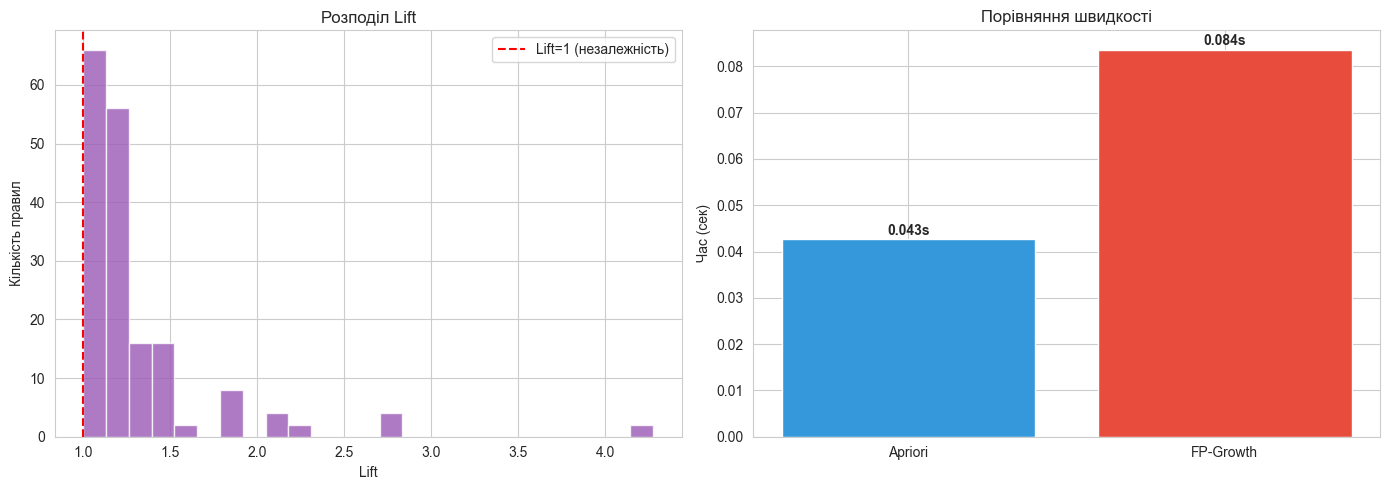

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл Lift
axes[0].hist(rules_fp['lift'], bins=25, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].axvline(x=1, color='red', linestyle='--', label='Lift=1 (незалежність)')
axes[0].set_xlabel('Lift')
axes[0].set_ylabel('Кількість правил')
axes[0].set_title('Розподіл Lift')
axes[0].legend()

# Порівняння часу
axes[1].bar(['Apriori', 'FP-Growth'], [apriori_time, fp_time], color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('Час (сек)')
axes[1].set_title('Порівняння швидкості')
for i, t in enumerate([apriori_time, fp_time]):
    axes[1].text(i, t + 0.001, f'{t:.3f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3.4 Порівняння з Apriori

In [5]:
print("="*60)
print("ПОРІВНЯННЯ APRIORI vs FP-GROWTH")
print("="*60)
print(f"{'Метрика':<30} {'Apriori':>12} {'FP-Growth':>12}")
print("-"*60)
print(f"{'Час виконання (сек)':<30} {apriori_time:>12.3f} {fp_time:>12.3f}")
print(f"{'Кількість частих наборів':<30} {len(frequent_fp):>12} {len(frequent_fp):>12}")
print(f"{'Кількість правил':<30} {len(rules_fp):>12} {len(rules_fp):>12}")
print("\nОбидва знаходять ОДНАКОВІ часті набори та правила.")
print("Різниця лише в ефективності: FP-Growth будує дерево, Apriori генерує кандидатів.")

ПОРІВНЯННЯ APRIORI vs FP-GROWTH
Метрика                             Apriori    FP-Growth
------------------------------------------------------------
Час виконання (сек)                   0.043        0.084
Кількість частих наборів                108          108
Кількість правил                        176          176

Обидва знаходять ОДНАКОВІ часті набори та правила.
Різниця лише в ефективності: FP-Growth будує дерево, Apriori генерує кандидатів.
